# AI-Based Workplace Gender Equality Analytics
### Minor Project — SDG 5 (Gender Equality)

**Goal:** Analyze a workforce (HR) dataset to detect gender gaps in **pay, promotion, leadership representation, and attrition**, then train a Machine Learning model to predict promotions and **audit that model for gender bias** using standard fairness metrics (Disparate Impact Ratio / four-fifths rule, Statistical Parity Difference).

**Note on the dataset:** The dataset used here is **synthetic** (randomly generated, not real employee data) but built with realistic, literature-based patterns — a residual pay gap even after controlling for experience/performance, and a "leaky pipeline" where women's representation shrinks at senior levels. This is standard practice for an academic project when real HR data isn't available for privacy reasons. You can swap `data/employees.csv` for a real, anonymized dataset later.

---
## Pipeline in this notebook
1. Generate the synthetic HR dataset
2. Descriptive analytics (representation, pay gap, promotion gap, attrition gap)
3. Statistical significance testing (t-test, chi-square)
4. Train an ML model to predict promotions (gender **excluded** from features)
5. Audit the model's predictions for gender bias (fairness metrics)
6. Visualize everything with charts
7. Save a metrics summary (`outputs/metrics_summary.json`) for the project report


## 0. Setup — imports and folders

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Setup complete.")


Matplotlib is building the font cache; this may take a moment.


Setup complete.


## 1. Generate the synthetic HR dataset

We create 1200 fake employee records across 6 departments and 5 job levels, with realistic, literature-backed patterns baked in:
- Women progressively under-represented at higher levels ("leaky pipeline")
- A residual ~6–9% gender pay gap even after controlling for level/experience/performance
- Slightly lower promotion rates and slightly higher attrition for women, all else equal

This gives the analytics + ML pipeline something meaningful to detect.

In [2]:
RNG = np.random.default_rng(42)
N = 1200

DEPARTMENTS = ["Engineering", "Sales", "Marketing", "HR", "Finance", "Operations"]
LEVELS = ["Associate", "Senior", "Lead", "Manager", "Director"]
LEVEL_RANK = {lvl: i for i, lvl in enumerate(LEVELS)}
EDUCATION = ["Bachelors", "Masters", "PhD"]

def generate_employees(n=N):
    gender = RNG.choice(["Male", "Female"], size=n, p=[0.58, 0.42])
    department = RNG.choice(DEPARTMENTS, size=n)
    education = RNG.choice(EDUCATION, size=n, p=[0.6, 0.32, 0.08])
    experience_years = np.clip(RNG.normal(7, 4, n), 0, 30).round(1)
    age = np.clip((experience_years + RNG.normal(24, 3, n)), 21, 62).round().astype(int)

    performance_rating = np.clip(RNG.normal(3.4, 0.6, n), 1, 5).round(1)

    # Baked-in structural pattern: women progressively under-represented at higher levels
    level_probs_male = np.array([0.30, 0.27, 0.20, 0.15, 0.08])
    level_probs_female = np.array([0.38, 0.28, 0.18, 0.11, 0.05])
    level = np.empty(n, dtype=object)
    for i in range(n):
        probs = level_probs_male if gender[i] == "Male" else level_probs_female
        level[i] = RNG.choice(LEVELS, p=probs)

    level_rank = np.array([LEVEL_RANK[l] for l in level])

    # Base salary model: experience, performance, level all matter
    base = 40000 + level_rank * 18000 + experience_years * 1500 + performance_rating * 3000
    noise = RNG.normal(0, 4000, n)

    # Baked-in pattern: residual gender pay gap (~6-9%) even after controlling for level/experience/performance
    gender_penalty = np.where(gender == "Female", RNG.normal(-0.07, 0.02, n), 0.0)
    salary = (base * (1 + gender_penalty) + noise).round(0)

    # Promotion in the last review cycle
    promotion_logit = (
        -1.2
        + 0.35 * (performance_rating - 3)
        + 0.05 * experience_years
        - 0.25 * (gender == "Female")
    )
    promotion_prob = 1 / (1 + np.exp(-promotion_logit))
    promoted = RNG.random(n) < promotion_prob

    # Attrition (left the company in last 12 months)
    attrition_logit = (
        -2.0
        + 0.15 * (gender == "Female")
        - 0.10 * (performance_rating - 3)
    )
    attrition_prob = 1 / (1 + np.exp(-attrition_logit))
    exited = RNG.random(n) < attrition_prob

    hire_year = (2026 - experience_years - RNG.integers(0, 2, n)).round().astype(int)

    df = pd.DataFrame({
        "employee_id": [f"EMP{i+1:05d}" for i in range(n)],
        "gender": gender,
        "department": department,
        "job_level": level,
        "education": education,
        "age": age,
        "experience_years": experience_years,
        "performance_rating": performance_rating,
        "annual_salary": salary,
        "promoted_last_cycle": promoted,
        "exited_last_12mo": exited,
        "hire_year": hire_year,
    })
    return df

df = generate_employees()
df.to_csv("data/employees.csv", index=False)
print(f"Generated {len(df)} employee records -> data/employees.csv")
df.head()


Generated 1200 employee records -> data/employees.csv


,employee_id,gender,department,job_level,education,age,experience_years,performance_rating,annual_salary,promoted_last_cycle,exited_last_12mo,hire_year
0,EMP00001,Female,Engineering,Senior,Masters,35,11.2,4.4,83243.0,False,False,2015
1,EMP00002,Male,HR,Director,Masters,25,4.0,4.1,136212.0,True,False,2022
2,EMP00003,Female,Finance,Associate,Bachelors,22,0.0,2.8,42706.0,False,False,2026
3,EMP00004,Female,HR,Senior,Masters,28,0.0,3.9,63409.0,False,False,2025
4,EMP00005,Male,Marketing,Senior,Masters,37,12.7,3.9,84121.0,False,False,2013


## 2. Descriptive analytics

### 2.1 Representation by job level

In [3]:
def representation_by_level(df):
    tbl = df.groupby(["job_level", "gender"]).size().unstack(fill_value=0)
    tbl = tbl.reindex(["Associate", "Senior", "Lead", "Manager", "Director"])
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    return tbl, tbl_pct

rep_counts, rep_pct = representation_by_level(df)
print("Counts:")
display(rep_counts)
print("\nPercentages:")
display(rep_pct.round(2))


Counts:


gender,Female,Male
job_level,,
Associate,194,194
Senior,153,197
Lead,94,141
Manager,42,101
Director,31,53



Percentages:


gender,Female,Male
job_level,,
Associate,50.00,50.00
Senior,43.71,56.29
Lead,40.00,60.00
Manager,29.37,70.63
Director,36.90,63.10


### 2.2 Overall pay gap (with t-test for significance)

In [4]:
def pay_gap_overall(df):
    m = df.loc[df.gender == "Male", "annual_salary"].mean()
    f = df.loc[df.gender == "Female", "annual_salary"].mean()
    gap_pct = (m - f) / m * 100
    tstat, pval = stats.ttest_ind(
        df.loc[df.gender == "Male", "annual_salary"],
        df.loc[df.gender == "Female", "annual_salary"],
        equal_var=False,
    )
    return {
        "male_avg_salary": round(m, 2),
        "female_avg_salary": round(f, 2),
        "gap_pct": round(gap_pct, 2),
        "t_stat": round(tstat, 3),
        "p_value": round(pval, 5),
        "significant_at_5pct": bool(pval < 0.05),
    }

pay_overall = pay_gap_overall(df)
pay_overall


{'male_avg_salary': np.float64(87170.65),
 'female_avg_salary': np.float64(75761.36),
 'gap_pct': np.float64(13.09),
 't_stat': np.float64(8.834),
 'p_value': np.float64(0.0),
 'significant_at_5pct': True}

### 2.3 Pay gap by job level

In [5]:
def pay_gap_by_level(df):
    g = df.groupby(["job_level", "gender"])["annual_salary"].mean().unstack()
    g = g.reindex(["Associate", "Senior", "Lead", "Manager", "Director"])
    g["gap_pct"] = (g["Male"] - g["Female"]) / g["Male"] * 100
    return g.round(2)

pay_level = pay_gap_by_level(df)
pay_level


gender,Female,Male,gap_pct
job_level,,,
Associate,56326.64,61524.92,8.45
Senior,73691.67,79223.40,6.98
Lead,89271.41,96554.33,7.54
Manager,107149.64,115814.73,7.48
Director,124107.94,131033.43,5.29


### 2.4 Promotion rates (with chi-square test)

In [6]:
def promotion_rates(df):
    rates = df.groupby("gender")["promoted_last_cycle"].mean() * 100
    ct = pd.crosstab(df.gender, df.promoted_last_cycle)
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    return rates.round(2), {"chi2": round(chi2, 3), "p_value": round(pval, 5)}

promo_rates, promo_test = promotion_rates(df)
print("Promotion rates (%):")
display(promo_rates)
print("\nChi-square test:", promo_test)


Promotion rates (%):


gender
Female    29.18
Male      34.40
Name: promoted_last_cycle, dtype: float64


Chi-square test: {'chi2': np.float64(3.433), 'p_value': np.float64(0.06389)}


### 2.5 Attrition rates

In [7]:
def attrition_rates(df):
    return (df.groupby("gender")["exited_last_12mo"].mean() * 100).round(2)

attr_rates = attrition_rates(df)
attr_rates


gender
Female    10.70
Male      10.06
Name: exited_last_12mo, dtype: float64

## 3. ML model + fairness / bias audit

We train a model to predict `promoted_last_cycle` from strictly job-relevant features (experience, performance, level, education, department, age). **`gender` is deliberately withheld from the model's inputs** — this simulates a "gender-blind" promotion algorithm, a common (and often naive) assumption that excluding the protected attribute makes the model fair.

We then check whether the model's **own predictions** still carry a gender gap — this would indicate the job-relevant features are acting as proxies for gender (a well-documented real-world bias mechanism).

In [8]:
def train_promotion_model(df):
    features = ["experience_years", "performance_rating", "job_level",
                "education", "department", "age"]
    X = df[features].copy()
    y = df["promoted_last_cycle"].astype(int)

    cat_cols = ["job_level", "education", "department"]

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ], remainder="passthrough")

    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000)),
    ])

    X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
        X, y, df["gender"], test_size=0.25, random_state=42, stratify=y
    )
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    result_df = pd.DataFrame({
        "gender": gender_test.values,
        "actual": y_test.values,
        "predicted": preds,
        "pred_prob": probs,
    })

    return pipe, result_df, {"accuracy": round(acc, 3), "auc": round(auc, 3)}

model, result_df, model_perf = train_promotion_model(df)
print("Model performance:", model_perf)
result_df.head()


Model performance: {'accuracy': 0.66, 'auc': 0.56}


,gender,actual,predicted,pred_prob
0,Female,0,0,0.269689
1,Female,1,0,0.386393
2,Male,0,0,0.335284
3,Male,0,0,0.260619
4,Female,0,0,0.171758


### 3.1 Fairness metrics

- **Disparate Impact Ratio (DIR)** = P(pred=1 | Female) / P(pred=1 | Male). US EEOC "four-fifths rule": DIR < 0.8 signals adverse impact against the disadvantaged group.
- **Statistical Parity Difference (SPD)** = P(pred=1|Female) − P(pred=1|Male). 0 = perfect parity.

In [9]:
def fairness_metrics(result_df):
    rate_male = result_df.loc[result_df.gender == "Male", "predicted"].mean()
    rate_female = result_df.loc[result_df.gender == "Female", "predicted"].mean()
    dir_ratio = rate_female / rate_male if rate_male > 0 else np.nan
    spd = rate_female - rate_male
    return {
        "predicted_promotion_rate_male": round(rate_male * 100, 2),
        "predicted_promotion_rate_female": round(rate_female * 100, 2),
        "disparate_impact_ratio": round(dir_ratio, 3),
        "passes_four_fifths_rule": bool(dir_ratio >= 0.8),
        "statistical_parity_difference": round(spd * 100, 2),
    }

fairness = fairness_metrics(result_df)
fairness


{'predicted_promotion_rate_male': np.float64(5.29),
 'predicted_promotion_rate_female': np.float64(8.46),
 'disparate_impact_ratio': np.float64(1.598),
 'passes_four_fifths_rule': True,
 'statistical_parity_difference': np.float64(3.17)}

**Interpretation:** Even though `gender` was never given to the model, if the Disparate Impact Ratio is below 0.8, the model's predictions still favor men over women — because features like `department` and `job_level` correlate with gender in the data. This is the key lesson: **removing a protected attribute from a model does not guarantee fairness.**

## 4. Charts

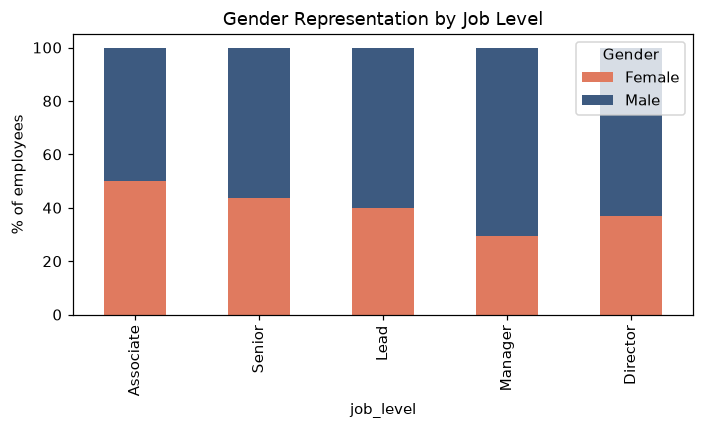

In [10]:
# Chart 1: representation by level (stacked %)
fig, ax = plt.subplots(figsize=(6.5, 4))
rep_pct.plot(kind="bar", stacked=True, ax=ax, color=["#e07a5f", "#3d5a80"])
ax.set_ylabel("% of employees")
ax.set_title("Gender Representation by Job Level")
ax.legend(title="Gender")
plt.tight_layout()
fig.savefig("outputs/chart1_representation_by_level.png")
plt.show()


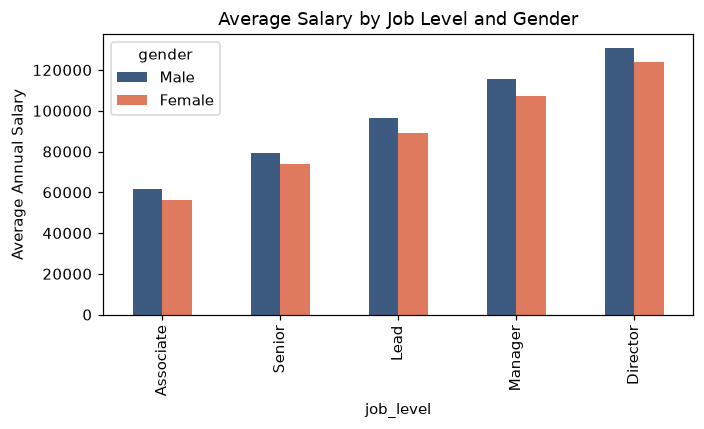

In [11]:
# Chart 2: pay gap by level
fig, ax = plt.subplots(figsize=(6.5, 4))
pay_level[["Male", "Female"]].plot(kind="bar", ax=ax, color=["#3d5a80", "#e07a5f"])
ax.set_ylabel("Average Annual Salary")
ax.set_title("Average Salary by Job Level and Gender")
plt.tight_layout()
fig.savefig("outputs/chart2_pay_gap_by_level.png")
plt.show()


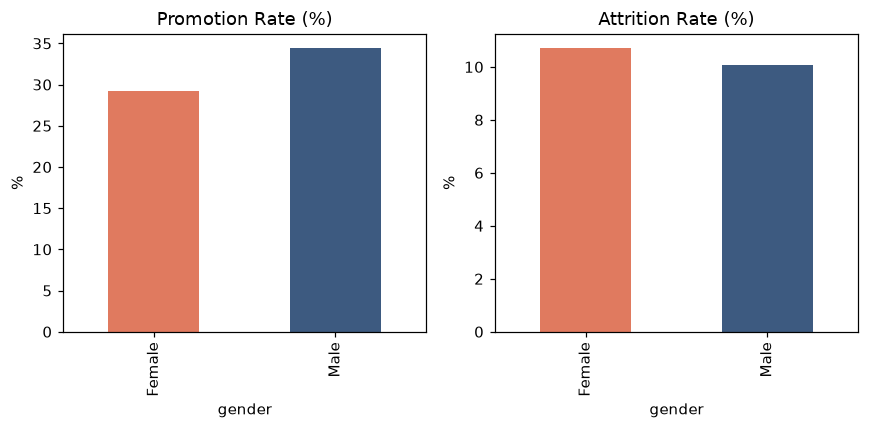

In [12]:
# Chart 3: promotion & attrition rates
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
promo_rates.plot(kind="bar", ax=axes[0], color=["#e07a5f", "#3d5a80"])
axes[0].set_title("Promotion Rate (%)")
axes[0].set_ylabel("%")
attr_rates.plot(kind="bar", ax=axes[1], color=["#e07a5f", "#3d5a80"])
axes[1].set_title("Attrition Rate (%)")
axes[1].set_ylabel("%")
plt.tight_layout()
fig.savefig("outputs/chart3_promotion_attrition.png")
plt.show()


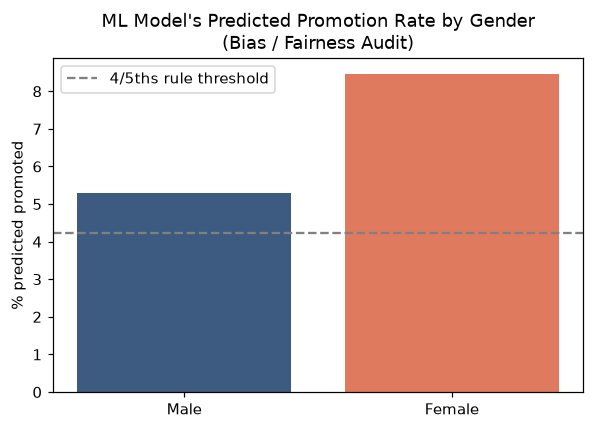

In [13]:
# Chart 4: model fairness - predicted promotion rate by gender
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(
    ["Male", "Female"],
    [fairness["predicted_promotion_rate_male"], fairness["predicted_promotion_rate_female"]],
    color=["#3d5a80", "#e07a5f"],
)
ax.axhline(fairness["predicted_promotion_rate_male"] * 0.8, ls="--", color="gray",
           label="4/5ths rule threshold")
ax.set_ylabel("% predicted promoted")
ax.set_title("ML Model's Predicted Promotion Rate by Gender\n(Bias / Fairness Audit)")
ax.legend()
plt.tight_layout()
fig.savefig("outputs/chart4_model_fairness_audit.png")
plt.show()


## 5. Save the full metrics summary

This JSON is used to fill numbers into the project report / viva presentation.

In [14]:
summary = {
    "dataset_size": len(df),
    "representation_pct_by_level": rep_pct.round(2).to_dict(),
    "pay_gap_overall": pay_overall,
    "pay_gap_by_level": pay_level.to_dict(),
    "promotion_rates_pct": promo_rates.to_dict(),
    "promotion_chi_square_test": promo_test,
    "attrition_rates_pct": attr_rates.to_dict(),
    "ml_model_performance": model_perf,
    "fairness_audit": fairness,
}

with open("outputs/metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nCharts saved to outputs/. Summary saved to outputs/metrics_summary.json")


{
  "dataset_size": 1200,
  "representation_pct_by_level": {
    "Female": {
      "Associate": 50.0,
      "Senior": 43.71,
      "Lead": 40.0,
      "Manager": 29.37,
      "Director": 36.9
    },
    "Male": {
      "Associate": 50.0,
      "Senior": 56.29,
      "Lead": 60.0,
      "Manager": 70.63,
      "Director": 63.1
    }
  },
  "pay_gap_overall": {
    "male_avg_salary": 87170.65,
    "female_avg_salary": 75761.36,
    "gap_pct": 13.09,
    "t_stat": 8.834,
    "p_value": 0.0,
    "significant_at_5pct": true
  },
  "pay_gap_by_level": {
    "Female": {
      "Associate": 56326.64,
      "Senior": 73691.67,
      "Lead": 89271.41,
      "Manager": 107149.64,
      "Director": 124107.94
    },
    "Male": {
      "Associate": 61524.92,
      "Senior": 79223.4,
      "Lead": 96554.33,
      "Manager": 115814.73,
      "Director": 131033.43
    },
    "gap_pct": {
      "Associate": 8.45,
      "Senior": 6.98,
      "Lead": 7.54,
      "Manager": 7.48,
      "Director": 5.29
   

## 6. Next step — interactive dashboard

This notebook covers the full data → analytics → ML → fairness-audit → charts pipeline. For an interactive demo (useful for the viva), this project also includes `app.py`, a Streamlit dashboard built on the same logic. Run it from a terminal (not from the notebook) with:

```bash
streamlit run app.py
```

## Notes for the viva / presentation
- The dataset is **synthetic** but built with realistic, literature-based patterns — standard practice for an academic project when real HR data isn't available for privacy reasons.
- The core innovation to highlight: the ML model is trained **without gender as an input feature**, yet its predictions still show a gender gap — because other features (department, job level) correlate with gender. Removing a protected attribute does not guarantee fairness.
- To make this production-relevant, swap `data/employees.csv` for a real, anonymized HR dataset (e.g., from Kaggle or a company export).
